# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Raihan Muzhaffar Athallah
- **Email:** raihanmuzhaffar18@gmail.com
- **ID Dicoding:** raihan_ahay_04

## Menentukan Pertanyaan Bisnis

**Konteks.** Dataset berisi rekap penyewaan sepeda sistem Capital Bikeshare di Washington D.C. per jam (`hour.csv`) dan per hari (`day.csv`) selama **1 Januari 2011 – 31 Desember 2012**, lengkap dengan data kalender dan cuaca. Bayangkan kita tim analis operator bike-sharing yang harus memutuskan **kapan armada disiapkan, bagaimana cuaca memengaruhi permintaan, dan ke mana strategi pertumbuhan diarahkan**.

Pertanyaan bisnis (disusun dengan metode SMART):

1. **Jam.** Pada pukul berapa rata-rata penyewaan per jam mencapai puncak pada hari kerja dibandingkan akhir pekan/hari libur, dan berapa persen penyewa pada jam-jam puncak tersebut adalah pengguna *registered*, selama 1 Januari 2011 – 31 Desember 2012?
   *Aksi:* menjadwalkan redistribusi sepeda, penempatan petugas, dan jendela perawatan.
2. **Cuaca dan musim.** Berapa persen rata-rata penyewaan harian turun saat cuaca berkabut/mendung dan hujan/salju ringan dibanding cuaca cerah, dan musim apa yang memiliki rata-rata penyewaan harian tertinggi dan terendah, selama 2011–2012?
   *Aksi:* menyesuaikan jumlah armada dan promo berdasarkan prakiraan cuaca dan musim.
3. **Pertumbuhan.** Berapa persen pertumbuhan total penyewaan dari 2011 ke 2012 (*year-over-year*), bulan apa yang tumbuh paling tinggi dan paling rendah, dan bagaimana perubahan porsi pengguna *casual* terhadap total?
   *Aksi:* menentukan bulan dan segmen pengguna yang perlu didorong melalui pemasaran dan keanggotaan.

## Import Semua Packages/Library yang Digunakan

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.2f}".format)

def idn(x, decimals=0):
    """Format a number with Indonesian separators, e.g. 1.234,5."""
    return f"{x:,.{decimals}f}".replace(",", "X").replace(".", ",").replace("X", ".")

# Design tokens: gray for context, one color per meaning
GRAY, BLUE, RED, GREEN, ORANGE = "#B8BEC7", "#2F5D8C", "#C0392B", "#2E8B6B", "#E8833A"
INK, MUTED = "#2B2F36", "#5B6270"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "text.color": INK,
    "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#E8EAEE", "axes.axisbelow": True,
})

## Data Wrangling

### Gathering Data
Dataset terdiri dari dua berkas: `day.csv` (rekap harian) dan `hour.csv` (rekap per jam). Keduanya dibaca menjadi DataFrame.

In [2]:
DATA_DIR = Path("data") if Path("data").exists() else Path("../data")

day_raw = pd.read_csv(DATA_DIR / "day.csv")
hour_raw = pd.read_csv(DATA_DIR / "hour.csv")
print(f"day.csv : {day_raw.shape[0]:,} rows x {day_raw.shape[1]} columns")
print(f"hour.csv: {hour_raw.shape[0]:,} rows x {hour_raw.shape[1]} columns")
day_raw.head()

day.csv : 731 rows x 16 columns
hour.csv: 17,379 rows x 17 columns


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.34,0.36,0.81,0.16,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.36,0.35,0.70,0.25,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.20,0.19,0.44,0.25,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.20,0.21,0.59,0.16,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.23,0.23,0.44,0.19,82,1518,1600


In [3]:
hour_raw.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.29,0.81,0.00,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.27,0.80,0.00,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.27,0.80,0.00,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.29,0.75,0.00,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.29,0.75,0.00,0,1,1


**Insight (Gathering Data):**
- `day.csv` berisi **731 baris** (satu baris per hari, 2011–2012) dan `hour.csv` berisi **17.379 baris** (satu baris per jam); `hour.csv` memiliki satu kolom tambahan, `hr`.
- Kolom terbagi menjadi tiga kelompok: kalender (`dteday`, `season`, `yr`, `mnth`, `holiday`, `weekday`, `workingday`), cuaca (`weathersit`, `temp`, `atemp`, `hum`, `windspeed`), dan target penyewaan (`casual`, `registered`, `cnt`).
- Hampir semua kolom kategori berupa kode angka dan variabel cuaca berada pada skala 0–1 (ternormalisasi), sehingga perlu diterjemahkan sebelum dianalisis.

### Assessing Data
Kualitas data dinilai dari: tipe data, *missing value* dan baris yang hilang, duplikasi, konsistensi antartabel, nilai tidak valid/tidak akurat (termasuk label `season` dan nilai nol yang mencurigakan), serta *outlier*.

In [4]:
day_raw.info()
print()
hour_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 98.6 KB

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Colu

In [5]:
# Missing values, duplicates and internal consistency
n_missing = int(day_raw.isna().sum().sum() + hour_raw.isna().sum().sum())
n_dups = int(day_raw.duplicated().sum() + hour_raw.duplicated().sum())
cnt_ok = bool((hour_raw["cnt"] == hour_raw["casual"] + hour_raw["registered"]).all()
              and (day_raw["cnt"] == day_raw["casual"] + day_raw["registered"]).all())

# day.csv should equal the daily sum of hour.csv
hour_daily = hour_raw.groupby("dteday")[["casual", "registered", "cnt"]].sum()
day_idx = day_raw.set_index("dteday")[["casual", "registered", "cnt"]]
n_day_mismatch = int((hour_daily.reindex(day_idx.index) != day_idx).any(axis=1).sum())

print(f"Missing values        : {n_missing}")
print(f"Duplicate rows        : {n_dups}")
print(f"cnt == casual + reg.  : {cnt_ok}")
print(f"Days where day.csv != sum of hour.csv: {n_day_mismatch} of {len(day_idx)}")

Missing values        : 0
Duplicate rows        : 0
cnt == casual + reg.  : True
Days where day.csv != sum of hour.csv: 0 of 731


In [6]:
# Season codes vs calendar months and temperature
day_raw["date"] = pd.to_datetime(day_raw["dteday"])
season_month = pd.crosstab(day_raw["season"], day_raw["mnth"])
season_temp = (day_raw["temp"] * 47 - 8).groupby(day_raw["season"]).mean()
display(season_month)
season_temp.round(1).to_frame("mean temp (C)").T

mnth,1,2,3,4,5,6,7,8,9,10,11,12
season,,,,,,,,,,,,
1,62,57,40,0,0,0,0,0,0,0,0,22
2,0,0,22,60,62,40,0,0,0,0,0,0
3,0,0,0,0,0,20,62,62,44,0,0,0
4,0,0,0,0,0,0,0,0,16,62,60,40


season,1,2,3,4
mean temp (C),6.00,17.60,25.20,11.90


In [7]:
# Hours that are absent from hour.csv
hour_raw["datetime"] = pd.to_datetime(hour_raw["dteday"]) + pd.to_timedelta(hour_raw["hr"], unit="h")
full_range = pd.date_range(hour_raw["datetime"].min(), hour_raw["datetime"].max(), freq="h")
missing_hours = full_range.difference(hour_raw["datetime"])
n_missing_hours = len(missing_hours)
pct_missing_hours = n_missing_hours / len(full_range) * 100
missing_by_hour = pd.Series(missing_hours.hour).value_counts().sort_index()
night_share = missing_by_hour.loc[0:5].sum() / n_missing_hours * 100
missing_by_day = pd.Series(missing_hours.normalize()).value_counts()
worst_day, worst_day_n = missing_by_day.index[0].date(), int(missing_by_day.iloc[0])
print(f"Expected {len(full_range):,} hours, found {len(hour_raw):,} -> {n_missing_hours} missing ({pct_missing_hours:.2f}%)")
print(f"{night_share:.0f}% of the missing hours fall between 00:00 and 05:59; worst day: {worst_day} ({worst_day_n} hours)")

Expected 17,544 hours, found 17,379 -> 165 missing (0.94%)
67% of the missing hours fall between 00:00 and 05:59; worst day: 2012-10-29 (23 hours)


In [8]:
# Suspicious zeros: wind speed and humidity
n_wind_zero = int((hour_raw["windspeed"] == 0).sum())
pct_wind_zero = n_wind_zero / len(hour_raw) * 100
min_wind_pos = hour_raw.loc[hour_raw["windspeed"] > 0, "windspeed"].min()
n_wind_zero_day = int((day_raw["windspeed"] == 0).sum())
n_allzero_days = int(hour_raw.groupby("dteday")["windspeed"].apply(lambda s: (s == 0).all()).sum())
hum_zero_days = day_raw.loc[day_raw["hum"] == 0, "dteday"].tolist()
n_hum_zero_hours = int((hour_raw["hum"] == 0).sum())
print(f"windspeed == 0: {n_wind_zero:,} hours ({pct_wind_zero:.1f}%), smallest non-zero value {min_wind_pos:.4f}; zeros in day.csv: {n_wind_zero_day}")
print(f"Days with windspeed == 0 for all 24 hours: {n_allzero_days}")
print(f"hum == 0 on days {hum_zero_days} ({n_hum_zero_hours} hours)")

windspeed == 0: 2,180 hours (12.5%), smallest non-zero value 0.0896; zeros in day.csv: 0
Days with windspeed == 0 for all 24 hours: 0
hum == 0 on days ['2011-03-10'] (22 hours)


In [9]:
# Outliers (IQR rule on hourly rentals) and extreme days
q1, q3 = hour_raw["cnt"].quantile([0.25, 0.75])
upper = q3 + 1.5 * (q3 - q1)
n_out = int((hour_raw["cnt"] > upper).sum())
pct_out = n_out / len(hour_raw) * 100
COMMUTE = [7, 8, 9, 16, 17, 18, 19]
pct_out_commute = hour_raw.loc[hour_raw["cnt"] > upper, "hr"].isin(COMMUTE).mean() * 100
day_min, day_max = day_raw.loc[day_raw["cnt"].idxmin()], day_raw.loc[day_raw["cnt"].idxmax()]
n_weather4 = int((hour_raw["weathersit"] == 4).sum())
print(f"IQR upper fence {upper:.0f}: {n_out:,} hours ({pct_out:.1f}%), {pct_out_commute:.0f}% of them in commute hours")
print(f"Lowest day {day_min['dteday']} = {day_min['cnt']}, highest day {day_max['dteday']} = {day_max['cnt']:,}; heavy-weather hours: {n_weather4}")
day_raw[["temp", "atemp", "hum", "windspeed", "casual", "registered", "cnt"]].describe().T

IQR upper fence 642: 505 hours (2.9%), 86% of them in commute hours
Lowest day 2012-10-29 = 22, highest day 2012-09-15 = 8,714; heavy-weather hours: 3


,count,mean,std,min,25%,50%,75%,max
temp,731.00,0.50,0.18,0.06,0.34,0.50,0.66,0.86
atemp,731.00,0.47,0.16,0.08,0.34,0.49,0.61,0.84
hum,731.00,0.63,0.14,0.00,0.52,0.63,0.73,0.97
windspeed,731.00,0.19,0.08,0.02,0.13,0.18,0.23,0.51
casual,731.00,848.18,686.62,2.00,315.50,713.00,"1,096.00","3,410.00"
registered,731.00,"3,656.17","1,560.26",20.00,"2,497.00","3,662.00","4,776.50","6,946.00"
cnt,731.00,"4,504.35","1,937.21",22.00,"3,152.00","4,548.00","5,956.00","8,714.00"


**Insight (Assessing Data):** ditemukan tujuh kelompok temuan beserta tindakannya.

| # | Masalah | Temuan | Tindakan pada Cleaning Data |
|---|---------|--------|-----------------------------|
| 1 | Tipe data dan struktur | `dteday` bertipe teks; waktu tersebar di `dteday` dan `hr`; `yr`, `mnth`, `weekday`, `weathersit` berupa kode angka. | Konversi ke `datetime` dan beri label yang terbaca. |
| 2 | *Inaccurate value*: label `season` | Dokumentasi menyebut 1 = *spring*, tetapi `season` 1 berisi **Januari–Maret** dan Desember, dengan suhu rata-rata terendah (6.0°C); `season` 3 terpanas (25.2°C). Kode ini sebenarnya musim astronomis: 1 = dingin, 2 = semi, 3 = panas, 4 = gugur. | Petakan ulang label sesuai bukti kalender dan suhu. |
| 3 | Representasi nilai | `temp`, `atemp`, `hum`, `windspeed` bernilai 0–1 (ternormalisasi) sehingga tidak bisa dibaca langsung. | Kembalikan ke °C, %, dan km/jam memakai rumus pada *Readme* dataset. |
| 4 | *Missing record* | `hour.csv` kehilangan **165 jam** (0.94%): 67% jatuh pada 00:00–05:59 dan terbanyak pada 2012-10-29 (23 jam, saat badai Sandy). Jam tanpa baris sangat mungkin jam tanpa penyewaan. | Lengkapi garis waktu per jam dan isi penyewaan dengan 0. |
| 5 | Nilai nol mencurigakan | `windspeed` = 0 pada 2.180 jam (12.5%) padahal nilai positif terkecil 0.090 dan `day.csv` tidak memiliki nol (hari dengan seluruh 24 jam bernilai 0: 0). `hum` = 0 pada 2011-03-10 (22 jam) mustahil secara fisik. | Anggap sebagai *missing* lalu isi dengan rata-rata hari yang sama (angin) atau interpolasi antarhari (kelembapan). |
| 6 | *Outlier* | IQR menandai 2.9% jam, 86% di antaranya pada jam komuter (sah). Hari terendah 2012-10-29 (22 sewa) bertepatan dengan badai Sandy; hanya 3 jam bercuaca ekstrem (`weathersit` 4). | Dipertahankan karena kejadian nyata. |
| 7 | Duplikasi dan konsistensi | Duplikat: 0; *missing value*: 0; `cnt` = `casual` + `registered`: True; hari yang tidak cocok antara `day.csv` dan agregat `hour.csv`: 0. | Tidak perlu tindakan; `day.csv` konsisten dengan `hour.csv`. |

### Cleaning Data
Langkah pembersihan mengikuti temuan pada Assessing Data:
1. **Harian:** ubah `dteday` menjadi `date`, perbaiki `hum` = 0 dengan interpolasi, dan dekode kolom kode serta kolom ternormalisasi.
2. **Per jam:** lengkapi garis waktu menjadi 17.544 jam (jam yang hilang diisi 0 penyewaan), perbaiki nilai nol pada `windspeed` dan `hum`, lalu dekode kolom.
3. **Pemetaan ulang `season`:** 1 = Dingin, 2 = Semi, 3 = Panas, 4 = Gugur (berdasarkan bulan dan suhu).
4. **Kolom turunan:** `day_group` (hari kerja vs akhir pekan & libur), nama hari, dan label cuaca.
5. Simpan data per jam yang bersih sebagai `dashboard/main_data.csv` untuk dashboard.

In [10]:
WEATHER = {1: "Cerah", 2: "Berkabut/Mendung", 3: "Hujan/Salju ringan", 4: "Hujan/Salju lebat"}
WEATHER_ORDER = ["Cerah", "Berkabut/Mendung", "Hujan/Salju ringan"]
SEASONS = {1: "Dingin", 2: "Semi", 3: "Panas", 4: "Gugur"}  # corrected mapping (see Assessing)
SEASON_ORDER = ["Dingin", "Semi", "Panas", "Gugur"]
WEEKDAYS = {0: "Minggu", 1: "Senin", 2: "Selasa", 3: "Rabu", 4: "Kamis", 5: "Jumat", 6: "Sabtu"}
MONTHS = ["Jan", "Feb", "Mar", "Apr", "Mei", "Jun", "Jul", "Agu", "Sep", "Okt", "Nov", "Des"]
DAY_GROUPS = ["Hari kerja", "Akhir pekan & libur"]

def decode(d):
    """Normalized columns back to real units (formulas from the dataset Readme)."""
    return pd.DataFrame({"temp_c": d["temp"] * 47 - 8, "atemp_c": d["atemp"] * 66 - 16,
                         "hum_pct": d["hum"] * 100, "wind_kmh": d["windspeed"] * 67}, index=d.index)

# ---- Daily table
day = day_raw.drop(columns=["instant", "dteday"]).sort_values("date").reset_index(drop=True)
n_hum_fixed_day = int((day["hum"] == 0).sum())
day["hum"] = day["hum"].replace(0, np.nan).interpolate()  # impossible 0% humidity -> interpolate between days
day = pd.concat([day, decode(day)], axis=1)
day["year"] = day["yr"].map({0: 2011, 1: 2012})
day["month"] = day["mnth"]
day["season"] = day["season"].map(SEASONS)
day["weekday_name"] = day["weekday"].map(WEEKDAYS)
day["weather"] = day["weathersit"].map(WEATHER)
day["day_group"] = np.where(day["workingday"] == 1, DAY_GROUPS[0], DAY_GROUPS[1])
day = day.drop(columns=["yr", "mnth", "temp", "atemp", "hum", "windspeed"])

# ---- Hourly table on a complete hourly timeline
hour = hour_raw.set_index("datetime").reindex(pd.date_range(hour_raw["datetime"].min(), hour_raw["datetime"].max(),
                                                           freq="h", name="datetime")).reset_index()
is_filled = hour["cnt"].isna()
n_filled = int(is_filled.sum())
hour.loc[is_filled, ["casual", "registered", "cnt"]] = 0       # hours absent from hour.csv = no rentals
hour[["casual", "registered", "cnt"]] = hour[["casual", "registered", "cnt"]].astype(int)
hour["date"] = hour["datetime"].dt.normalize()
hour["hour"] = hour["datetime"].dt.hour

day_cal = day.set_index("date")[["year", "month", "season", "weekday", "weekday_name", "holiday", "workingday", "day_group",
                                  "weather", "temp_c", "atemp_c", "hum_pct", "wind_kmh"]]
day_cal.columns = [c if c in ("year", "month", "season", "weekday", "weekday_name", "holiday", "workingday", "day_group")
                   else c + "_day" for c in day_cal.columns]
hour = pd.concat([hour[["datetime", "date", "hour", "casual", "registered", "cnt", "weathersit", "temp", "atemp", "hum", "windspeed"]],
                  decode(hour)], axis=1).join(day_cal, on="date")

# Zero wind speed / zero humidity are placeholders: fill with same-day values, then with day.csv values
n_wind_fixed = int((hour["wind_kmh"] <= 0).sum())
n_hum_fixed_hour = int((hour["hum_pct"] <= 0).sum())
hour["wind_kmh"] = hour["wind_kmh"].mask(hour["wind_kmh"] <= 0)
hour["wind_kmh"] = hour["wind_kmh"].fillna(hour.groupby("date")["wind_kmh"].transform("mean")).fillna(hour["wind_kmh_day"])
hour["hum_pct"] = hour["hum_pct"].mask(hour["hum_pct"] <= 0).fillna(hour["hum_pct_day"])
hour["temp_c"] = hour["temp_c"].fillna(hour["temp_c_day"])
hour["atemp_c"] = hour["atemp_c"].fillna(hour["atemp_c_day"])
hour["weather"] = hour["weathersit"].map(WEATHER).fillna(hour["weather_day"])
hour = hour.drop(columns=["weathersit", "temp", "atemp", "hum", "windspeed"])

# Sanity check: totals must still match day.csv
assert hour["cnt"].sum() == day["cnt"].sum(), "hourly and daily totals differ"
print(f"hour: {len(hour):,} rows ({n_filled} filled), day: {len(day):,} rows; total rentals {day['cnt'].sum():,}")
hour.head()

hour: 17,544 rows (165 filled), day: 731 rows; total rentals 3,292,679


,datetime,date,hour,casual,registered,cnt,temp_c,atemp_c,hum_pct,wind_kmh,year,month,season,weekday,weekday_name,holiday,workingday,day_group,weather_day,temp_c_day,atemp_c_day,hum_pct_day,wind_kmh_day,weather
0,2011-01-01 00:00:00,2011-01-01,0,3,13,16,3.28,3.00,81.00,17.20,2011,1,Dingin,6,Sabtu,0,0,Akhir pekan & libur,Berkabut/Mendung,8.18,8.00,80.58,10.75,Cerah
1,2011-01-01 01:00:00,2011-01-01,1,8,32,40,2.34,2.00,80.00,17.20,2011,1,Dingin,6,Sabtu,0,0,Akhir pekan & libur,Berkabut/Mendung,8.18,8.00,80.58,10.75,Cerah
2,2011-01-01 02:00:00,2011-01-01,2,5,27,32,2.34,2.00,80.00,17.20,2011,1,Dingin,6,Sabtu,0,0,Akhir pekan & libur,Berkabut/Mendung,8.18,8.00,80.58,10.75,Cerah
3,2011-01-01 03:00:00,2011-01-01,3,3,10,13,3.28,3.00,75.00,17.20,2011,1,Dingin,6,Sabtu,0,0,Akhir pekan & libur,Berkabut/Mendung,8.18,8.00,80.58,10.75,Cerah
4,2011-01-01 04:00:00,2011-01-01,4,0,1,1,3.28,3.00,75.00,17.20,2011,1,Dingin,6,Sabtu,0,0,Akhir pekan & libur,Berkabut/Mendung,8.18,8.00,80.58,10.75,Cerah


In [11]:
# Export the cleaned hourly data for the Streamlit dashboard
export_cols = ["datetime", "hour", "year", "month", "season", "weekday_name", "holiday", "workingday", "day_group",
               "weather", "weather_day", "temp_c", "hum_pct", "wind_kmh", "casual", "registered", "cnt"]
out_dir = DATA_DIR.parent / "dashboard"
out_dir.mkdir(exist_ok=True)
hour[export_cols].round({"temp_c": 1, "hum_pct": 1, "wind_kmh": 1}).to_csv(out_dir / "main_data.csv", index=False)
print(f"{out_dir / 'main_data.csv'} saved: {len(hour):,} rows x {len(export_cols)} columns")

dashboard/main_data.csv saved: 17,544 rows x 17 columns


**Insight (Cleaning Data):**
- Garis waktu per jam kini lengkap (**17.544 jam** = 731 hari × 24); **165 jam** yang hilang ditambahkan dengan penyewaan 0. Total penyewaan tetap **3.292.679** dan sama persis dengan `day.csv`, sehingga tidak ada data yang bergeser.
- 2.180 nilai `windspeed` = 0 dan 22 nilai `hum` = 0 diperlakukan sebagai *missing* lalu diisi; kelembapan hari 2011-03-10 diinterpolasi dari hari-hari di sekitarnya.
- Label musim sudah benar (1 = Dingin, 2 = Semi, 3 = Panas, 4 = Gugur) dan semua variabel cuaca kini berada pada satuan nyata (rata-rata harian): suhu -5.2–32.5°C, kelembapan 19–97%, angin hingga 34 km/jam.
- Data bersih disimpan sebagai `dashboard/main_data.csv` agar notebook dan dashboard memakai angka yang sama.

## Exploratory Data Analysis (EDA)
Eksplorasi dilakukan per pertanyaan bisnis memakai agregasi dan statistik deskriptif. Analisis per jam memakai `hour` (garis waktu lengkap), sedangkan analisis per hari memakai `day`.

### Explore: Pertanyaan 1 (Jam)

In [12]:
profile = hour.pivot_table(index="hour", columns="day_group", values="cnt", aggfunc="mean")[DAY_GROUPS]
wk, we = profile[DAY_GROUPS[0]], profile[DAY_GROUPS[1]]
am_peak, pm_peak = int(wk.loc[6:10].idxmax()), int(wk.loc[15:20].idxmax())
we_peak, low_h = int(we.idxmax()), int(wk.idxmin())

# Share of registered users at each peak hour
by_group_hour = hour.groupby(["day_group", "hour"])[["registered", "casual", "cnt"]].sum()
def reg_pct(group, h):
    row = by_group_hour.loc[(group, h)]
    return row["registered"] / row["cnt"] * 100
reg_am, reg_pm, reg_we = reg_pct(DAY_GROUPS[0], am_peak), reg_pct(DAY_GROUPS[0], pm_peak), reg_pct(DAY_GROUPS[1], we_peak)

totals = hour.groupby("day_group")[["registered", "cnt"]].sum()
reg_total = totals["registered"] / totals["cnt"] * 100
wk_hours = hour[hour["day_group"] == DAY_GROUPS[0]]
commute_share = wk_hours.loc[wk_hours["hour"].isin(COMMUTE), "cnt"].sum() / wk_hours["cnt"].sum() * 100
night_share_wk = wk_hours.loc[wk_hours["hour"].between(0, 5), "cnt"].sum() / wk_hours["cnt"].sum() * 100
pm_vs_noon = wk[pm_peak] / wk.loc[10:15].mean()

display(profile.round(0).T)
pd.DataFrame({"registered %": [reg_am, reg_pm, reg_we]}, index=[f"workday {am_peak:02d}:00", f"workday {pm_peak:02d}:00", f"weekend {we_peak:02d}:00"]).round(1)

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
day_group,,,,,,,,,,,,,,,,,,,,,,,,
Hari kerja,36.00,16.00,8.00,5.00,5.00,25.00,102.00,288.00,473.00,240.00,134.00,157.00,200.00,198.00,183.00,201.00,293.00,524.00,490.00,347.00,249.00,186.00,138.00,88.00
Akhir pekan & libur,90.00,69.00,52.00,25.00,8.00,8.00,19.00,43.00,106.00,172.00,256.00,315.00,366.00,373.00,365.00,359.00,353.00,324.00,280.00,231.00,174.00,141.00,116.00,86.00


,registered %
workday 08:00,95.30
workday 17:00,89.20
weekend 13:00,63.40


**Insight (EDA, Pertanyaan 1):**
- **Hari kerja** memiliki dua puncak komuter: **08:00** (473 sewa/jam) dan **17:00** (524 sewa/jam); puncak sore 2.9× lebih tinggi daripada rata-rata jam siang (10:00–15:59). Titik terendah pada pukul 03:00 (5 sewa/jam).
- **Akhir pekan dan libur** hanya memiliki satu puncak siang pada **13:00** (373 sewa/jam), dengan kurva yang lebih landai.
- Tujuh jam komuter (07:00–09:59 dan 16:00–19:59) menampung **58%** penyewaan hari kerja; jam 00:00–05:59 hanya 2.1%.
- Pada puncak hari kerja, pengguna *registered* mencapai **95%** (08:00) dan **89%** (17:00), sedangkan pada puncak akhir pekan turun menjadi **63%**; pengguna *casual* mengisi 37%. Secara keseluruhan *registered* 87% pada hari kerja dan 68% pada akhir pekan & libur.

### Explore: Pertanyaan 2 (Cuaca dan Musim)

In [13]:
by_weather = day.groupby("weather")["cnt"].agg(mean="mean", median="median", count="count").loc[WEATHER_ORDER]
by_season = day.groupby("season")["cnt"].agg(mean="mean", median="median", count="count").loc[SEASON_ORDER]
by_season["temp_c"] = day.groupby("season")["temp_c"].mean()

drop = (by_weather["mean"] / by_weather.loc["Cerah", "mean"] - 1) * 100
top_season, low_season = by_season["mean"].idxmax(), by_season["mean"].idxmin()
season_gap = (by_season["mean"].max() / by_season["mean"].min() - 1) * 100
r_temp, r_hum, r_wind = (day["cnt"].corr(day[c]) for c in ("temp_c", "hum_pct", "wind_kmh"))

display(by_weather.assign(change_vs_clear_pct=drop).round(1))
display(by_season.round(1))
pd.Series({"temp_c": r_temp, "hum_pct": r_hum, "wind_kmh": r_wind}, name="Pearson r with daily rentals").round(2).to_frame().T

,mean,median,count,change_vs_clear_pct
weather,,,,
Cerah,"4,876.80","4,844.00",463,0.00
Berkabut/Mendung,"4,035.90","4,040.00",247,-17.20
Hujan/Salju ringan,"1,803.30","1,817.00",21,-63.00


,mean,median,count,temp_c
season,,,,
Dingin,"2,604.10","2,209.00",181,6.00
Semi,"4,992.30","4,941.50",184,17.60
Panas,"5,644.30","5,353.50",188,25.20
Gugur,"4,728.20","4,634.50",178,11.90


,temp_c,hum_pct,wind_kmh
Pearson r with daily rentals,0.63,-0.12,-0.23


**Insight (EDA, Pertanyaan 2):**
- Dibanding hari cerah (4.877 sewa/hari), rata-rata penyewaan turun **17%** saat berkabut/mendung (4.036) dan **63%** saat hujan/salju ringan (1.803). Hari hujan/salju ringan jarang (21 dari 731 hari).
- Musim **Panas** tertinggi (5.644 sewa/hari, suhu rata-rata 25.2°C) dan musim **Dingin** terendah (2.604, 6.0°C); musim tertinggi **117%** lebih ramai.
- Suhu berkorelasi positif kuat dengan penyewaan harian (r = +0.63), sedangkan kelembapan (-0.12) dan kecepatan angin (-0.23) berkorelasi negatif lemah.

### Explore: Pertanyaan 3 (Pertumbuhan)

In [14]:
year_tot = day.groupby("year")[["casual", "registered", "cnt"]].sum()
yoy_total = (year_tot.loc[2012, "cnt"] / year_tot.loc[2011, "cnt"] - 1) * 100
yoy_casual = (year_tot.loc[2012, "casual"] / year_tot.loc[2011, "casual"] - 1) * 100
yoy_reg = (year_tot.loc[2012, "registered"] / year_tot.loc[2011, "registered"] - 1) * 100
casual_share = year_tot["casual"] / year_tot["cnt"] * 100

monthly = day.pivot_table(index="month", columns="year", values="cnt", aggfunc="sum")
yoy_month = (monthly[2012] / monthly[2011] - 1) * 100
best_m, worst_m = int(yoy_month.idxmax()), int(yoy_month.idxmin())
yoy_h1 = (monthly.loc[1:6, 2012].sum() / monthly.loc[1:6, 2011].sum() - 1) * 100
yoy_h2 = (monthly.loc[7:12, 2012].sum() / monthly.loc[7:12, 2011].sum() - 1) * 100

display(year_tot.assign(casual_share_pct=casual_share))
monthly.assign(yoy_pct=yoy_month).round(1).T

,casual,registered,cnt,casual_share_pct
year,,,,
2011,247252,995851,1243103,19.89
2012,372765,1676811,2049576,18.19


month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2011,"38,189.00","48,215.00","64,045.00","94,870.00","135,821.00","143,512.00","141,341.00","136,691.00","127,418.00","123,511.00","102,167.00","87,323.00"
2012,"96,744.00","103,137.00","164,875.00","174,224.00","195,865.00","202,830.00","203,607.00","214,503.00","218,573.00","198,841.00","152,664.00","123,713.00"
yoy_pct,153.30,113.90,157.40,83.60,44.20,41.30,44.10,56.90,71.50,61.00,49.40,41.70


**Insight (EDA, Pertanyaan 3):**
- Total penyewaan naik dari **1.243.103** (2011) menjadi **2.049.576** (2012), atau **+64.9%**.
- Pertumbuhan tertinggi pada **Mar** (+157%) dan terendah pada **Jun** (+41%). Semester pertama tumbuh +79% dan semester kedua +55%; sebagian lonjakan awal tahun berasal dari basis 2011 yang masih rendah.
- Pengguna *registered* tumbuh **+68.4%** sedangkan *casual* +50.8%, sehingga porsi *casual* turun dari 19.9% (2011) menjadi 18.2% (2012).

## Visualization & Explanatory Analysis
Setiap visualisasi mengikuti prinsip desain dan integritas grafis berikut:
- **Judul memuat pesan utama**; subjudul menjelaskan ukuran dan periode data; sumber data dicantumkan.
- **Warna untuk menekankan, bukan menghias**: abu-abu untuk konteks, hijau untuk penyewaan tertinggi/pertumbuhan terbaik, merah untuk yang terendah, biru dan oranye untuk membedakan jenis pengguna (*registered* dan *casual*).
- **Sumbu nilai dimulai dari nol** pada grafik batang dan garis agar selisih visual sebanding dengan selisih data; satuan selalu ditulis.
- **Label langsung** pada garis/batang, garis acuan, *gridline* tipis, dan tanpa bingkai atas/kanan agar tidak ada *chart junk*.
- **Ukuran sampel (*n*)** dan sebaran data (titik hari individual) ditampilkan agar rata-rata tidak menyesatkan.

In [15]:
SOURCE = "Sumber: Capital Bikeshare (UCI Bike Sharing Dataset), 1 Jan 2011 – 31 Des 2012"
REG, CAS, WE_COLOR = BLUE, ORANGE, "#7C8696"

def add_titles(fig, title, subtitle):
    """Left-aligned takeaway title, subtitle and source note."""
    fig.suptitle(title, x=0.01, y=0.985, ha="left", fontsize=13.5, fontweight="bold", color=INK)
    fig.text(0.01, 0.915, subtitle, ha="left", fontsize=9.5, color=MUTED)
    fig.text(0.01, 0.012, SOURCE, ha="left", fontsize=8, color=MUTED)

def mark(ax, x, y, text, color, dx, dy, ha):
    """Dot on a peak with a label in the same color."""
    ax.scatter([x], [y], color=color, s=36, zorder=3)
    ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points", ha=ha, fontsize=9,
                color=color, fontweight="bold")

### Pertanyaan 1: Kapan puncak penyewaan dan siapa penyewanya?
*Pada pukul berapa rata-rata penyewaan per jam mencapai puncak pada hari kerja dibandingkan akhir pekan/hari libur, dan berapa persen penyewa pada jam-jam puncak tersebut adalah pengguna registered, selama 1 Januari 2011 – 31 Desember 2012?*

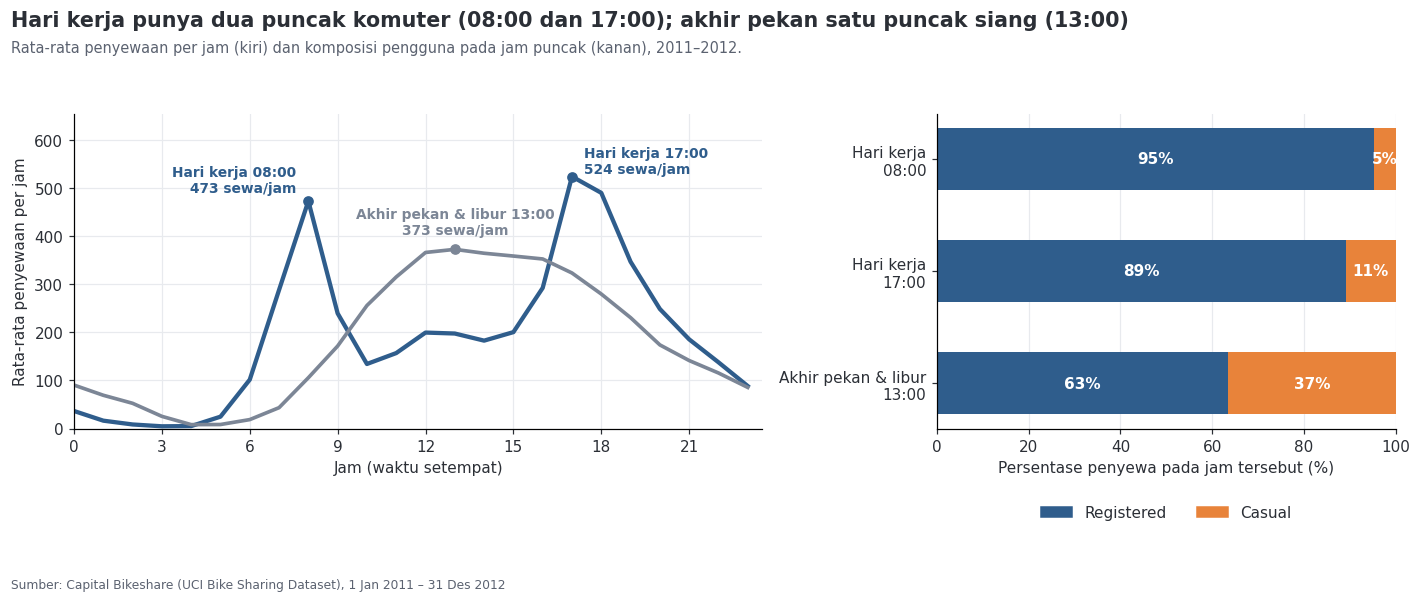

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), gridspec_kw={"width_ratios": [1.5, 1]})

# Left: hourly profile, workday vs weekend/holiday
ax = axes[0]
ax.plot(wk.index, wk.values, color=BLUE, lw=2.8)
ax.plot(we.index, we.values, color=WE_COLOR, lw=2.4)
mark(ax, am_peak, wk[am_peak], f"Hari kerja {am_peak:02d}:00\n{wk[am_peak]:.0f} sewa/jam", BLUE, -8, 6, "right")
mark(ax, pm_peak, wk[pm_peak], f"Hari kerja {pm_peak:02d}:00\n{wk[pm_peak]:.0f} sewa/jam", BLUE, 8, 2, "left")
mark(ax, we_peak, we[we_peak], f"Akhir pekan & libur {we_peak:02d}:00\n{we[we_peak]:.0f} sewa/jam", WE_COLOR, 0, 10, "center")
ax.set_xlim(0, 23.5)
ax.set_ylim(0, wk.max() * 1.25)
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("Jam (waktu setempat)")
ax.set_ylabel("Rata-rata penyewaan per jam")

# Right: user mix at the three peak hours
ax = axes[1]
cats = [f"Hari kerja\n{am_peak:02d}:00", f"Hari kerja\n{pm_peak:02d}:00", f"Akhir pekan & libur\n{we_peak:02d}:00"]
reg = np.array([reg_am, reg_pm, reg_we])
y = np.arange(3)[::-1]
ax.barh(y, reg, color=REG, height=0.55)
ax.barh(y, 100 - reg, left=reg, color=CAS, height=0.55)
for yi, r in zip(y, reg):
    ax.text(r / 2, yi, f"{r:.0f}%", ha="center", va="center", color="white", fontweight="bold")
    ax.text(r + (100 - r) / 2, yi, f"{100 - r:.0f}%", ha="center", va="center", color="white", fontweight="bold")
ax.set_yticks(y, cats)
ax.set_xlim(0, 100)
ax.set_xlabel("Persentase penyewa pada jam tersebut (%)")
ax.grid(axis="y", visible=False)
ax.legend(handles=[Patch(color=REG, label="Registered"), Patch(color=CAS, label="Casual")], loc="upper center",
          bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False)

add_titles(fig,
           f"Hari kerja punya dua puncak komuter ({am_peak:02d}:00 dan {pm_peak:02d}:00); akhir pekan satu puncak siang ({we_peak:02d}:00)",
           "Rata-rata penyewaan per jam (kiri) dan komposisi pengguna pada jam puncak (kanan), 2011–2012.")
plt.tight_layout(rect=[0, 0.04, 1, 0.9])
plt.show()

**Insight (Explanatory Analysis, Pertanyaan 1):**
- Grafik kiri memperlihatkan dua pola penggunaan yang berbeda: **komuter** pada hari kerja (puncak ganda 08:00 dan 17:00, dengan lembah siang) dan **rekreasi** pada akhir pekan/libur (satu puncak landai 13:00). Puncak sore hari kerja (524) adalah yang tertinggi dari semua jam.
- Grafik kanan: pada puncak komuter, **89–95%** penyewa adalah *registered*; pada puncak akhir pekan porsi *casual* melonjak menjadi **37%**. Artinya jam puncak hari kerja digerakkan pelanggan tetap, sedangkan akhir pekan adalah peluang menjaring pengguna baru.
- Karena **58%** penyewaan hari kerja terjadi pada tujuh jam komuter, ketersediaan sepeda dan dok pada jam-jam itulah yang paling menentukan kualitas layanan.

### Pertanyaan 2: Seberapa besar cuaca dan musim memengaruhi penyewaan?
*Berapa persen rata-rata penyewaan harian turun saat cuaca berkabut/mendung dan hujan/salju ringan dibanding cuaca cerah, dan musim apa yang memiliki rata-rata penyewaan harian tertinggi dan terendah, selama 2011–2012?*

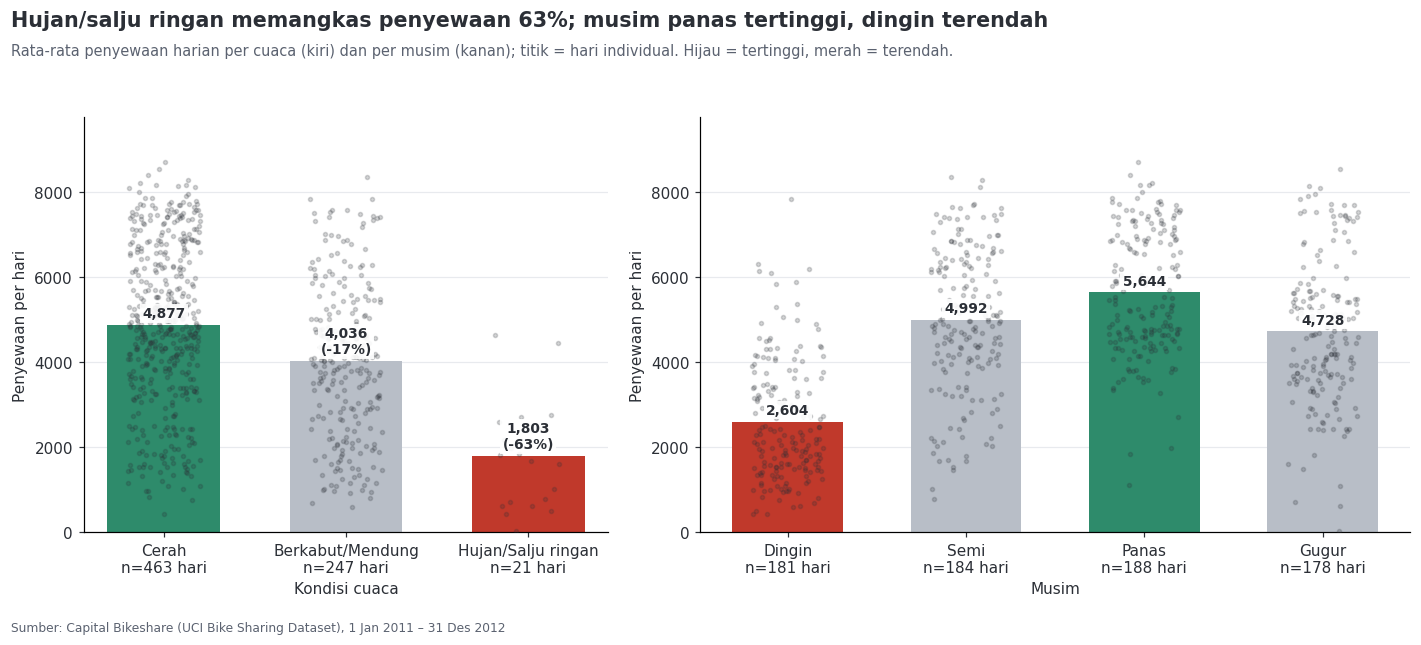

In [17]:
rng = np.random.default_rng(7)  # jitter for the daily points

def group_bars(ax, col, order, colors, labels):
    """Mean daily rentals per group, with every day shown as a faint dot."""
    stats = day.groupby(col)["cnt"].agg(["mean", "count"]).loc[order]
    x = np.arange(len(order))
    bars = ax.bar(x, stats["mean"], color=colors, width=0.62, zorder=2)
    for i, g in enumerate(order):
        pts = day.loc[day[col] == g, "cnt"]
        ax.scatter(i + rng.uniform(-0.2, 0.2, len(pts)), pts, s=7, color=INK, alpha=0.2, zorder=3)
    ax.bar_label(bars, labels=labels, padding=3, fontsize=9, fontweight="bold",
                 bbox=dict(facecolor="white", edgecolor="none", pad=1.5, alpha=0.9))
    ax.set_xticks(x, [f"{g}\nn={int(c)} hari" for g, c in zip(order, stats["count"])])
    ax.set_ylim(0, day["cnt"].max() * 1.12)
    ax.set_ylabel("Penyewaan per hari")
    ax.grid(axis="x", visible=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.8), gridspec_kw={"width_ratios": [0.85, 1.15]})
w_labels = [f"{by_weather.loc[w, 'mean']:,.0f}" + ("" if w == "Cerah" else f"\n({drop[w]:+.0f}%)") for w in WEATHER_ORDER]
group_bars(axes[0], "weather", WEATHER_ORDER, [GREEN, GRAY, RED], w_labels)
s_colors = [GREEN if s == top_season else RED if s == low_season else GRAY for s in SEASON_ORDER]
group_bars(axes[1], "season", SEASON_ORDER, s_colors, [f"{by_season.loc[s, 'mean']:,.0f}" for s in SEASON_ORDER])
axes[0].set_xlabel("Kondisi cuaca")
axes[1].set_xlabel("Musim")

add_titles(fig,
           f"Hujan/salju ringan memangkas penyewaan {abs(drop['Hujan/Salju ringan']):.0f}%; musim {top_season.lower()} tertinggi, {low_season.lower()} terendah",
           "Rata-rata penyewaan harian per cuaca (kiri) dan per musim (kanan); titik = hari individual. Hijau = tertinggi, merah = terendah.")
plt.tight_layout(rect=[0, 0.04, 1, 0.9])
plt.show()

**Insight (Explanatory Analysis, Pertanyaan 2):**
- Grafik kiri: dibanding hari cerah, penyewaan turun **17%** saat berkabut/mendung dan **63%** saat hujan/salju ringan. Titik-titik hari hujan hampir semuanya berada di bawah rata-rata hari cerah, sehingga penurunannya konsisten, bukan akibat beberapa hari ekstrem.
- Grafik kanan: musim **Panas** menghasilkan 5.644 sewa/hari, sedangkan **Dingin** hanya 2.604; selisih **117%**. Suhu menjelaskan sebagian besar pola ini (r = +0.63).
- Sebaran titik yang lebar pada setiap batang menunjukkan bahwa cuaca dan musim bukan satu-satunya penentu; hari kerja vs libur dan tren pertumbuhan juga berperan (lihat Pertanyaan 1 dan 3).

### Pertanyaan 3: Seberapa cepat layanan tumbuh dan siapa yang tumbuh?
*Berapa persen pertumbuhan total penyewaan dari 2011 ke 2012 (year-over-year), bulan apa yang tumbuh paling tinggi dan paling rendah, dan bagaimana perubahan porsi pengguna casual terhadap total?*

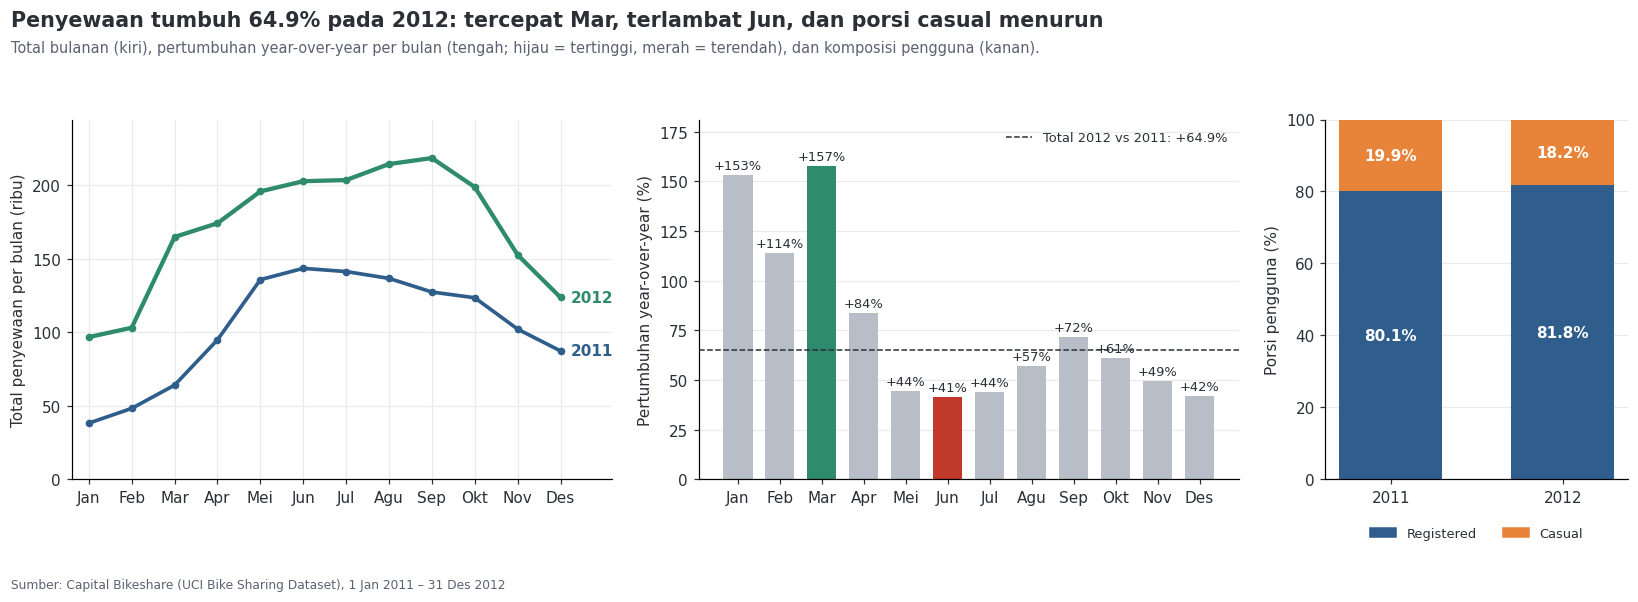

In [18]:
fmt_k = FuncFormatter(lambda v, _: f"{v / 1000:.0f}")
fig, axes = plt.subplots(1, 3, figsize=(15, 5.4), gridspec_kw={"width_ratios": [1.25, 1.25, 0.7]})

# Left: monthly totals
ax = axes[0]
ax.plot(range(12), monthly[2011].values, color=BLUE, lw=2.4, marker="o", ms=4)
ax.plot(range(12), monthly[2012].values, color=GREEN, lw=2.8, marker="o", ms=4)
ax.text(11.25, monthly.loc[12, 2011], "2011", color=BLUE, va="center", fontweight="bold")
ax.text(11.25, monthly.loc[12, 2012], "2012", color=GREEN, va="center", fontweight="bold")
ax.set_xticks(range(12), MONTHS)
ax.set_xlim(-0.4, 12.2)
ax.set_ylim(0, monthly.max().max() * 1.12)
ax.yaxis.set_major_formatter(fmt_k)
ax.set_ylabel("Total penyewaan per bulan (ribu)")

# Middle: year-over-year growth per month
ax = axes[1]
g_colors = [GREEN if m == best_m else RED if m == worst_m else GRAY for m in yoy_month.index]
bars = ax.bar(range(12), yoy_month.values, color=g_colors, width=0.7)
ax.bar_label(bars, fmt="%+.0f%%", padding=2, fontsize=8.5)
ax.axhline(yoy_total, color=INK, ls="--", lw=1, label=f"Total 2012 vs 2011: {yoy_total:+.1f}%")
ax.legend(loc="upper right", frameon=False, fontsize=8.5)
ax.set_xticks(range(12), MONTHS)
ax.set_ylim(0, yoy_month.max() * 1.15)
ax.set_ylabel("Pertumbuhan year-over-year (%)")
ax.grid(axis="x", visible=False)

# Right: user mix per year
ax = axes[2]
ax.bar([0, 1], 100 - casual_share.values, color=REG, width=0.6)
ax.bar([0, 1], casual_share.values, bottom=100 - casual_share.values, color=CAS, width=0.6)
for i, c in enumerate(casual_share.values):
    ax.text(i, (100 - c) / 2, f"{100 - c:.1f}%", ha="center", va="center", color="white", fontweight="bold")
    ax.text(i, 100 - c / 2, f"{c:.1f}%", ha="center", va="center", color="white", fontweight="bold")
ax.set_xticks([0, 1], ["2011", "2012"])
ax.set_ylim(0, 100)
ax.set_ylabel("Porsi pengguna (%)")
ax.grid(axis="x", visible=False)
ax.legend(handles=[Patch(color=REG, label="Registered"), Patch(color=CAS, label="Casual")], loc="upper center",
          bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False, fontsize=8.5)

add_titles(fig,
           f"Penyewaan tumbuh {yoy_total:.1f}% pada 2012: tercepat {MONTHS[best_m - 1]}, terlambat {MONTHS[worst_m - 1]}, dan porsi casual menurun",
           "Total bulanan (kiri), pertumbuhan year-over-year per bulan (tengah; hijau = tertinggi, merah = terendah), dan komposisi pengguna (kanan).")
plt.tight_layout(rect=[0, 0.04, 1, 0.9])
plt.show()

**Insight (Explanatory Analysis, Pertanyaan 3):**
- Grafik kiri: kurva 2012 berada di atas 2011 pada **seluruh bulan** dan pola musimannya sama (puncak pertengahan tahun), sehingga pertumbuhan bersifat struktural, bukan musiman.
- Grafik tengah: pertumbuhan tertinggi Mar (+157%) dan terendah Jun (+41%). Lonjakan awal tahun sebagian besar efek basis rendah 2011; pada Mei–Juli pertumbuhan melandai ke 41–44%, dan semester kedua tumbuh +55% secara keseluruhan.
- Grafik kanan: *registered* tumbuh lebih cepat (+68%) daripada *casual* (+51%), sehingga porsi *casual* turun dari 19.9% menjadi 18.2%. Basis pelanggan tetap menguat, tetapi pengguna kasual belum cukup dikonversi.

## Analisis Lanjutan: Manual Grouping (Binning)

Teknik yang dipakai adalah ***manual grouping* dengan *binning* (`pd.cut`)**, tanpa algoritma *machine learning*. Tujuan tiap pengelompokan:
1. **Segmen waktu** (dini hari, pagi, siang, sore, malam): meringkas 24 jam menjadi lima jendela operasional agar jadwal redistribusi, petugas, dan perawatan mudah ditentukan.
2. **Bin suhu 5°C**: menemukan rentang suhu dengan penyewaan tertinggi dan titik suhu ketika permintaan mulai turun, sebagai dasar prakiraan permintaan berbasis cuaca.
3. **Tier permintaan harian** (Rendah / Sedang / Tinggi): mengelompokkan hari menurut volume penyewaan lalu melihat musim dan cuaca mana yang paling sering menghasilkan hari berpermintaan tinggi atau rendah. Batas 3.000 dan 6.000 adalah pembulatan kuartil pertama dan ketiga penyewaan harian.

In [19]:
SEGMENTS = ["Dini hari (00–05)", "Pagi (06–09)", "Siang (10–15)", "Sore (16–19)", "Malam (20–23)"]
hour["segment"] = pd.cut(hour["hour"], bins=[-1, 5, 9, 15, 19, 23], labels=SEGMENTS)
seg_tab = hour.pivot_table(index="segment", columns="day_group", values="cnt", aggfunc="sum", observed=True)
seg_share = (seg_tab / seg_tab.sum() * 100)[DAY_GROUPS]

TEMP_LABELS = ["<0", "0–5", "5–10", "10–15", "15–20", "20–25", "25–30", "30–35", "≥35"]
hour["temp_bin"] = pd.cut(hour["temp_c"], bins=[-10, 0, 5, 10, 15, 20, 25, 30, 35, 50], labels=TEMP_LABELS, right=False)
by_temp = hour.groupby("temp_bin", observed=True)["cnt"].agg(mean="mean", count="count")
best_t, worst_t = by_temp["mean"].idxmax(), by_temp["mean"].idxmin()
cold_mean = hour.loc[hour["temp_c"] < 10, "cnt"].mean()
cold_gap = (cold_mean / by_temp["mean"].max() - 1) * 100
hot_gap = (by_temp.loc["≥35", "mean"] / by_temp["mean"].max() - 1) * 100 if "≥35" in by_temp.index else np.nan

display(seg_share.round(1))
by_temp.round(1).T

day_group,Hari kerja,Akhir pekan & libur
segment,,
Dini hari (00–05),2.10,5.90
Pagi (06–09),24.10,7.80
Siang (10–15),23.40,47.00
Sore (16–19),36.10,27.40
Malam (20–23),14.40,11.90


temp_bin,<0,0–5,5–10,10–15,15–20,20–25,25–30,30–35,≥35
mean,56.40,76.00,132.90,167.10,205.80,224.30,315.90,330.80,292.80
count,569.00,"2,078.00","3,281.00","2,546.00","2,545.00","3,833.00","1,983.00",625.00,84.00


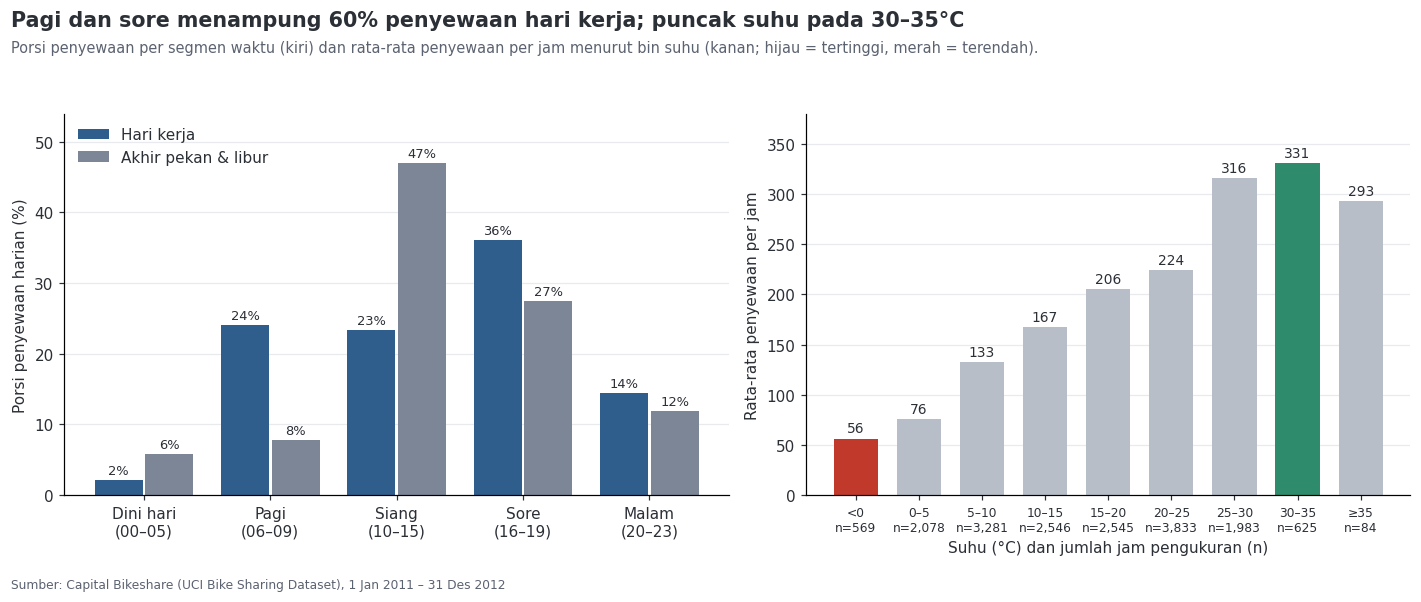

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), gridspec_kw={"width_ratios": [1.1, 1]})

# Left: share of rentals per time segment
ax = axes[0]
x = np.arange(len(SEGMENTS))
for off, grp, color in [(-0.2, DAY_GROUPS[0], BLUE), (0.2, DAY_GROUPS[1], WE_COLOR)]:
    bars = ax.bar(x + off, seg_share[grp].values, width=0.38, color=color, label=grp)
    ax.bar_label(bars, fmt="%.0f%%", padding=2, fontsize=8.5)
ax.set_xticks(x, [s.replace(" (", "\n(") for s in SEGMENTS])
ax.set_ylim(0, seg_share.max().max() * 1.15)
ax.set_ylabel("Porsi penyewaan harian (%)")
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, loc="upper left")

# Right: mean hourly rentals per 5-degree temperature bin
ax = axes[1]
t_colors = [GREEN if b == best_t else RED if b == worst_t else GRAY for b in by_temp.index]
bars = ax.bar(range(len(by_temp)), by_temp["mean"], color=t_colors, width=0.7)
ax.bar_label(bars, fmt="%.0f", padding=2, fontsize=9)
ax.set_xticks(range(len(by_temp)), [f"{b}\nn={c:,}" for b, c in zip(by_temp.index, by_temp["count"])], fontsize=8)
ax.set_ylim(0, by_temp["mean"].max() * 1.15)
ax.set_xlabel("Suhu (°C) dan jumlah jam pengukuran (n)")
ax.set_ylabel("Rata-rata penyewaan per jam")
ax.grid(axis="x", visible=False)

add_titles(fig,
           f"Pagi dan sore menampung {seg_share.loc[SEGMENTS[1], DAY_GROUPS[0]] + seg_share.loc[SEGMENTS[3], DAY_GROUPS[0]]:.0f}% penyewaan hari kerja; puncak suhu pada {best_t}°C",
           "Porsi penyewaan per segmen waktu (kiri) dan rata-rata penyewaan per jam menurut bin suhu (kanan; hijau = tertinggi, merah = terendah).")
plt.tight_layout(rect=[0, 0.04, 1, 0.9])
plt.show()

**Insight (Binning: segmen waktu dan suhu):**
- Segmen **pagi** (24%) dan **sore** (36%) menampung 60% penyewaan hari kerja, sedangkan pada akhir pekan bobotnya bergeser ke **siang** (47%) dan sore (27%). Dini hari hanya 2% (hari kerja), jendela terbaik untuk perawatan dan redistribusi.
- Rata-rata penyewaan per jam tertinggi pada suhu **30–35°C** (331 sewa/jam) dan terendah pada **<0°C** (56). Seluruh jam dengan suhu di bawah 10°C rata-rata hanya 106 sewa/jam, atau **68% lebih rendah** daripada bin terbaik.
- Pada bin terpanas (≥35°C, n = 84 jam) rata-rata 293 sewa/jam, 11% di bawah puncak: kenaikan suhu membantu hingga batas tertentu, setelah itu permintaan tidak lagi bertambah.

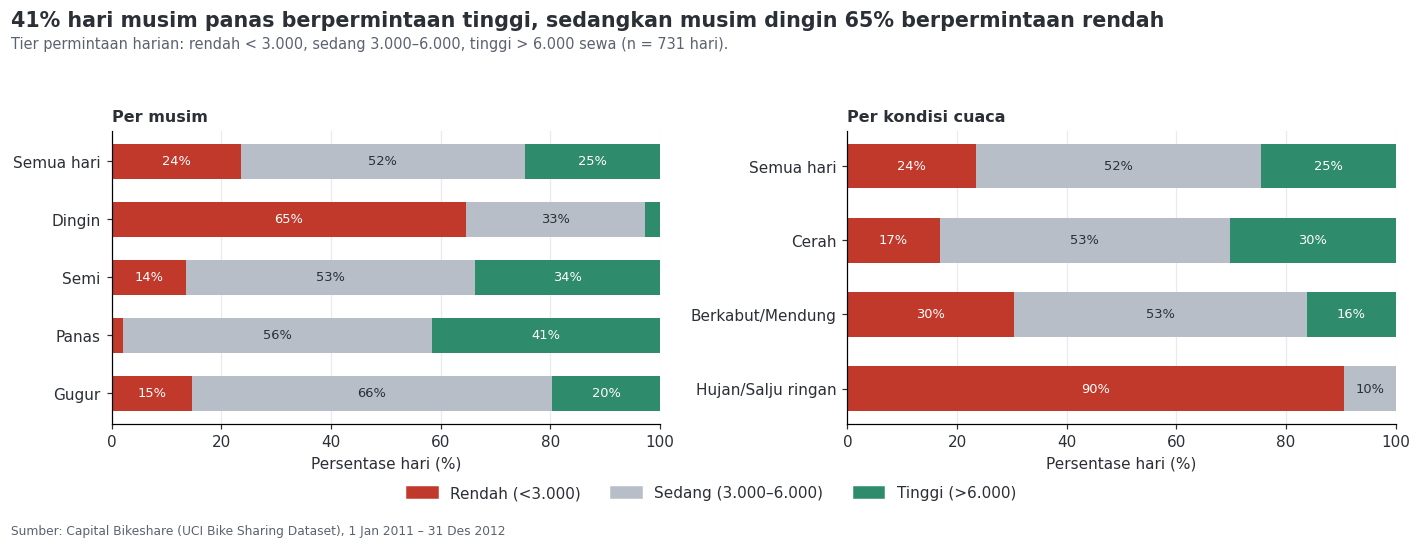

tier,Rendah (<3.000),Sedang (3.000–6.000),Tinggi (>6.000)
Semua hari,23.50,51.80,24.60
Dingin,64.60,32.60,2.80
Semi,13.60,52.70,33.70
Panas,2.10,56.40,41.50
Gugur,14.60,65.70,19.70
Cerah,16.80,52.90,30.20
Berkabut/Mendung,30.40,53.40,16.20
Hujan/Salju ringan,90.50,9.50,0.00


In [21]:
TIERS = ["Rendah (<3.000)", "Sedang (3.000–6.000)", "Tinggi (>6.000)"]
TIER_COLORS = [RED, GRAY, GREEN]
day["tier"] = pd.cut(day["cnt"], bins=[0, 3000, 6000, np.inf], labels=TIERS, include_lowest=True)
q1_day, q3_day = day["cnt"].quantile([0.25, 0.75])

tier_all = day["tier"].value_counts(normalize=True).reindex(TIERS).to_frame("Semua hari").T * 100
tier_season = pd.crosstab(day["season"], day["tier"], normalize="index").loc[SEASON_ORDER] * 100
tier_weather = pd.crosstab(day["weather"], day["tier"], normalize="index").loc[WEATHER_ORDER] * 100
high, low = TIERS[2], TIERS[0]

def stacked(ax, table, title):
    """100% stacked horizontal bars of demand tiers."""
    rows = list(table.index[::-1])
    left = np.zeros(len(rows))
    for tier, color in zip(TIERS, TIER_COLORS):
        vals = table.loc[rows, tier].values
        ax.barh(rows, vals, left=left, color=color, height=0.6, label=tier)
        for i, (v, l) in enumerate(zip(vals, left)):
            if v >= 5:
                ax.text(l + v / 2, i, f"{v:.0f}%", ha="center", va="center", fontsize=8.5,
                        color="white" if tier != TIERS[1] else INK)
        left += vals
    ax.set_xlim(0, 100)
    ax.set_xlabel("Persentase hari (%)")
    ax.set_title(title, fontsize=10.5)
    ax.grid(axis="y", visible=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.9))
stacked(axes[0], pd.concat([tier_all, tier_season]), "Per musim")
stacked(axes[1], pd.concat([tier_all, tier_weather]), "Per kondisi cuaca")
handles = [Patch(color=c, label=t) for t, c in zip(TIERS, TIER_COLORS)]
fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.05))
add_titles(fig,
           f"{tier_season.loc[top_season, high]:.0f}% hari musim {top_season.lower()} berpermintaan tinggi, sedangkan musim {low_season.lower()} {tier_season.loc[low_season, low]:.0f}% berpermintaan rendah",
           f"Tier permintaan harian: rendah < 3.000, sedang 3.000–6.000, tinggi > 6.000 sewa (n = {len(day)} hari).")
plt.tight_layout(rect=[0, 0.1, 1, 0.9])
plt.show()
pd.concat([tier_all, tier_season, tier_weather]).round(1)

**Insight (Binning: tier permintaan):**
- Batas 3.000 dan 6.000 mendekati kuartil pertama (3.152) dan ketiga (5.956), sehingga kira-kira seperempat hari masuk tier rendah (24%) dan seperempat tier tinggi (25%).
- **Musim:** 41% hari musim panas berpermintaan tinggi, sedangkan musim dingin hampir tidak pernah (3%) dan 65% harinya berpermintaan rendah.
- **Cuaca:** hari cerah berpermintaan tinggi 30% dan rendah 17%; saat hujan/salju ringan 90% hari berpermintaan rendah dan 0% tinggi.
- Pengelompokan ini langsung dapat dipakai sebagai aturan operasional: prakiraan musim dan cuaca dikonversi menjadi tier permintaan yang menentukan jumlah sepeda dan petugas.

## Conclusion

- **Kesimpulan Pertanyaan 1 (jam):** hari kerja dipimpin dua puncak komuter pada **08:00** (473 sewa/jam) dan **17:00** (524), sedangkan akhir pekan/libur memuncak sekali pada **13:00** (373). Pada puncak hari kerja **89–95%** penyewa adalah *registered*; pada puncak akhir pekan *registered* turun menjadi **63%** (*casual* 37%). Tujuh jam komuter menampung 58% penyewaan hari kerja.
- **Kesimpulan Pertanyaan 2 (cuaca dan musim):** penyewaan harian turun **17%** saat berkabut/mendung dan **63%** saat hujan/salju ringan dibanding hari cerah. Musim **Panas** tertinggi (5.644 sewa/hari) dan **Dingin** terendah (2.604), selisih 117%; suhu berkorelasi kuat dengan penyewaan harian (r = +0.63).
- **Kesimpulan Pertanyaan 3 (pertumbuhan):** total penyewaan tumbuh **+64.9%** dari 1.243.103 (2011) ke 2.049.576 (2012). Pertumbuhan tertinggi pada Mar (+157%) dan terendah pada Jun (+41%). Pengguna *registered* tumbuh +68% dan *casual* +51%, sehingga porsi *casual* turun dari 19.9% ke 18.2%.
- **Analisis lanjutan:** pagi + sore menampung 60% penyewaan hari kerja; rentang suhu **30–35°C** menghasilkan penyewaan per jam tertinggi, sedangkan suhu < 10°C 68% lebih rendah. Hari berpermintaan tinggi (> 6.000) mencapai 41% pada musim panas tetapi 3% pada musim dingin.

### Rekomendasi (Action Items)
1. **Jadwalkan armada dan petugas mengikuti jam komuter.** Pastikan stok sepeda dan dok kosong tersedia sebelum 08:00 dan 17:00 pada hari kerja (tujuh jam komuter = 58% penyewaan), dan geser fokus ke siang hari (13:00) pada akhir pekan dan libur.
2. **Pakai jendela dini hari untuk perawatan dan redistribusi.** Jam 00:00–05:59 hanya 2% penyewaan hari kerja sehingga gangguan layanan minimal.
3. **Terapkan perencanaan armada berbasis cuaca dan musim.** Kurangi sepeda yang disebar saat prakiraan hujan/salju (penyewaan turun 63%), tawarkan promo pada hari berkabut/mendung (17% lebih rendah), dan manfaatkan musim dingin (penyewaan terendah) untuk perbaikan armada serta promo musim dingin.
4. **Konversi pengguna *casual* menjadi anggota.** Porsi *casual* turun ke 18.2% dan menyentuh 37% pada puncak akhir pekan: kampanye keanggotaan di akhir pekan dan musim panas adalah peluang terbesar.
5. **Waspadai perlambatan pertumbuhan.** Pertumbuhan melandai ke sekitar 41–44% pada pertengahan tahun; rencanakan kapasitas 2013 dengan skenario konservatif tersebut, bukan dengan lonjakan awal 2012.
6. **Perbaiki pencatatan data.** Catat jam tanpa penyewaan, hindari nilai 0 sebagai pengganti data kosong pada kecepatan angin, dan tambahkan data stasiun/lokasi agar analisis redistribusi spasial dapat dilakukan.